In [1]:
!unzip -qo fashion_recsys.zip
%cd fashion_recsys

/content/fashion_recsys


In [2]:
!pip install -q kagglehub
import kagglehub
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
!mkdir -p /content/fashion
!cp -r {path}/. /content/fashion/
!ls /content/fashion

Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
images	myntradataset  styles.csv


In [16]:
import sys
sys.path.extend([".", "fashion_recsys"])

import numpy as np
from IPython.display import display
from config import *
import data, features, scratch, analysis, serve

In [17]:
cat = data.load_catalogue()
small = data.load_small(cat.paths)

4976 products, 75 types, train 3980 / query 996


In [18]:
# pretrained resnet-50 and vit-b/16, plus the cnn autoencoder trained from scratch
emb, cost = features.pretrained_embeddings(cat.paths)
emb["CNN Autoencoder (scratch)"], cost["CNN Autoencoder (scratch)"] = scratch.train_autoencoder(small, cat.train_idx)

resnet50_avg:   0%|          | 0/78 [00:00<?, ?it/s]

resnet50_gem:   0%|          | 0/78 [00:00<?, ?it/s]

vit_cls:   0%|          | 0/78 [00:00<?, ?it/s]

vit_mean:   0%|          | 0/78 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b5bd8466020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b5bd8466020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

In [19]:
vit_df, vit_embs, vit_cost = analysis.vit_ablation(small, cat)
base = vit_df.index[0]
emb["ViT (scratch)"], cost["ViT (scratch)"] = vit_embs[base], vit_cost[base]
emb["Random"] = np.random.default_rng(SEED).standard_normal((len(cat.df), 64))
vit_df.round(3)

,Patch,Pool,Pos,Tokens,MAP@10,P@10,Params (M),Train (s)
Config,,,,,,,,
p8 cls learned,8,cls,learned,64,0.117,0.190,0.843,4.533
p8 mean learned,8,mean,learned,64,0.141,0.219,0.843,4.453
p4 cls learned,4,cls,learned,256,0.099,0.171,0.849,20.718
p16 cls learned,16,cls,learned,16,0.135,0.211,0.911,2.266
p8 cls none,8,cls,none,64,0.120,0.197,0.835,4.574


best: ViT-B/16 (CLS)


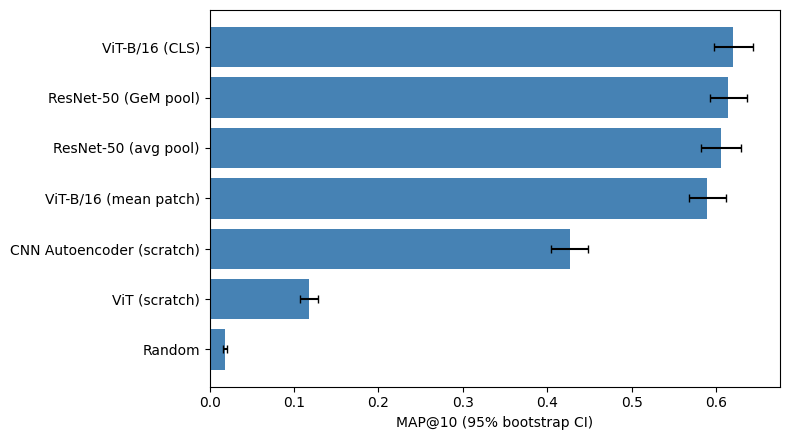

,Dim,P@10,MAP@10,MAP_lo,MAP_hi,R@10
Method,,,,,,
ViT-B/16 (CLS),768,0.685,0.620,0.598,0.644,0.070
ResNet-50 (GeM pool),2048,0.682,0.614,0.593,0.637,0.073
ResNet-50 (avg pool),2048,0.676,0.605,0.582,0.629,0.071
ViT-B/16 (mean patch),768,0.657,0.589,0.567,0.612,0.068
CNN Autoencoder (scratch),128,0.512,0.427,0.405,0.448,0.049
ViT (scratch),128,0.190,0.117,0.107,0.128,0.015
Random,64,0.048,0.018,0.015,0.021,0.002


In [20]:
results, best = analysis.compare(emb, cat)
print("best:", best)
analysis.plot_comparison(results)
results[["Dim", f"P@{K}", f"MAP@{K}", "MAP_lo", "MAP_hi", f"R@{K}"]].round(3)

In [21]:
analysis.paired(emb, cat, "ViT-B/16 (CLS)", "ResNet-50 (avg pool)")
analysis.paired(emb, cat, "ViT-B/16 (CLS)", "ViT-B/16 (mean patch)")
analysis.paired(emb, cat, "ResNet-50 (GeM pool)", "ResNet-50 (avg pool)")

ViT-B/16 (CLS) - ResNet-50 (avg pool): +0.015 MAP@10  (95% CI +0.002 to +0.027)
ViT-B/16 (CLS) - ViT-B/16 (mean patch): +0.031 MAP@10  (95% CI +0.018 to +0.044)
ResNet-50 (GeM pool) - ResNet-50 (avg pool): +0.009 MAP@10  (95% CI +0.001 to +0.016)


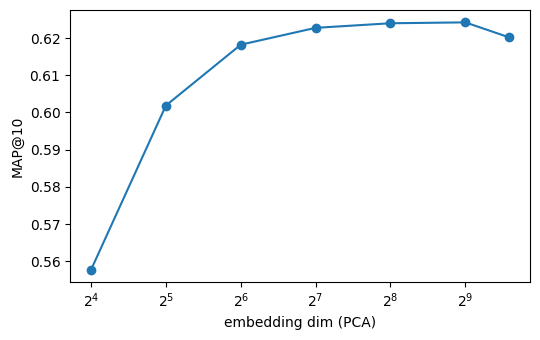

cosine vs euclidean (resnet-50): {'cosine': 0.6055, 'euclidean': 0.5956}


,Dim,MAP@10,P@10,Index MB
0,16,0.558,0.635,0.318
1,32,0.602,0.672,0.637
2,64,0.618,0.684,1.274
3,128,0.623,0.688,2.548
4,256,0.624,0.689,5.095
5,512,0.624,0.689,10.191
6,768,0.620,0.685,15.286


In [22]:
pca_df = analysis.pca_ablation(emb[best], cat)
print("cosine vs euclidean (resnet-50):", analysis.metric_ablation(emb["ResNet-50 (avg pool)"], cat))
pca_df.round(3)

In [23]:
analysis.relevance_table(emb, [best, "ResNet-50 (avg pool)", "CNN Autoencoder (scratch)", "ViT (scratch)"], cat).round(3)

Relevance,master_category,article_type,type+colour
Method,,,
CNN Autoencoder (scratch),0.894,0.427,0.113
ResNet-50 (avg pool),0.973,0.605,0.171
ViT (scratch),0.522,0.117,0.047
ViT-B/16 (CLS),0.974,0.620,0.181


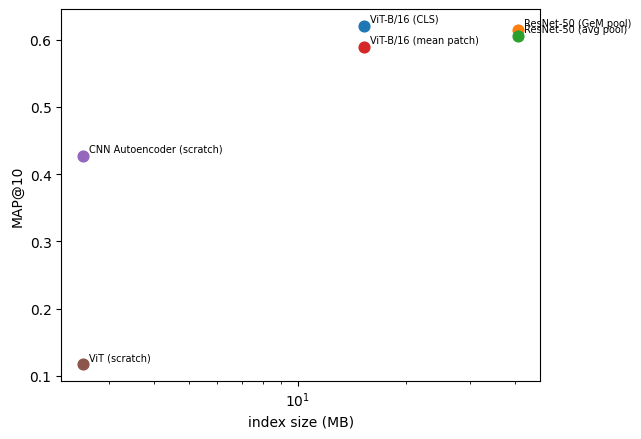

,Params (M),Dim,Time (s),Index (MB),Query (ms),MAP@10
Method,,,,,,
ViT-B/16 (CLS),86.568,768,16.271,15.286,0.185,0.620
ResNet-50 (GeM pool),25.557,2048,12.884,40.763,0.275,0.614
ResNet-50 (avg pool),25.557,2048,13.061,40.763,0.275,0.605
ViT-B/16 (mean patch),86.568,768,16.768,15.286,0.191,0.589
CNN Autoencoder (scratch),0.503,128,5.871,2.548,0.125,0.427
ViT (scratch),0.843,128,4.533,2.548,0.087,0.117


In [24]:
cost_df = analysis.cost_table(emb, cost, results)
cost_df.round(3)

,mean,count
type,,
Clutches,0.189,9
Flats,0.200,11
Dresses,0.244,9
Tops,0.403,35
Sandals,0.448,21
Heels,0.470,30
Track Pants,0.475,8
Casual Shoes,0.541,64
Jeans,0.571,14


,count
Casual Shoes -> Formal Shoes,14
Sports Shoes -> Casual Shoes,11
Casual Shoes -> Sports Shoes,8
Tshirts -> Tops,8
Tops -> Tshirts,7
Tops -> Kurtas,5
Shirts -> Tshirts,5
Formal Shoes -> Casual Shoes,5
Heels -> Flats,5
Tshirts -> Shirts,5


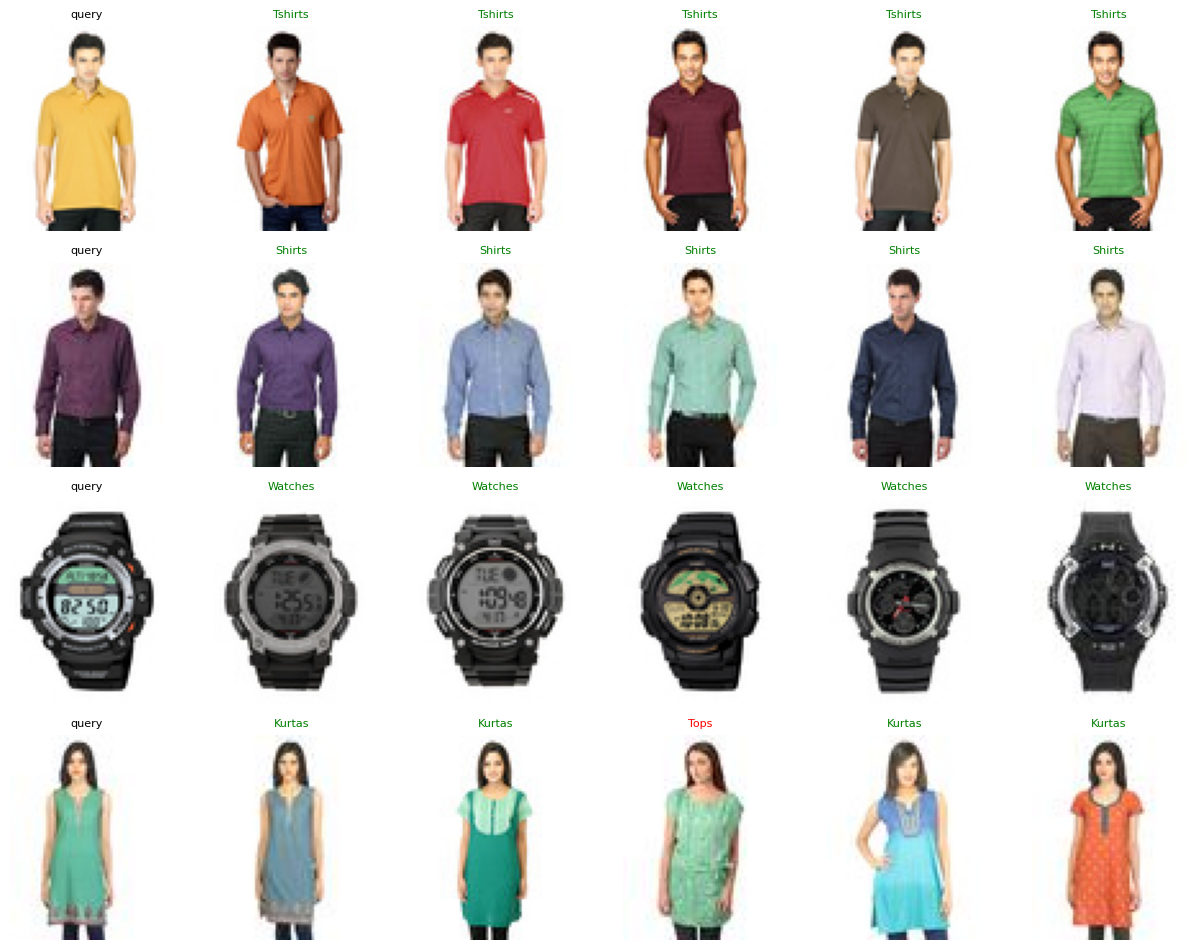

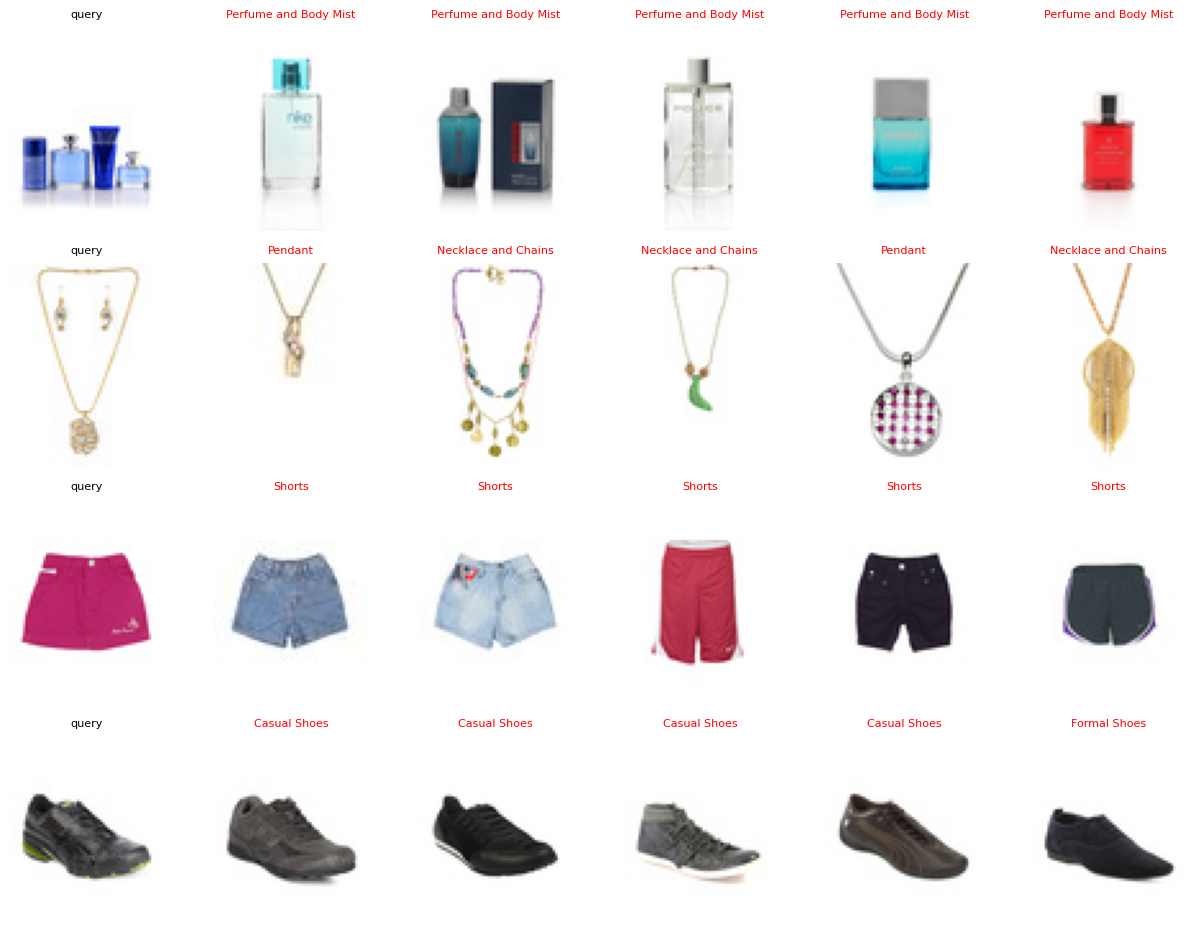

In [25]:
worst_classes, confusions, worst_q = analysis.error_analysis(emb[best], cat)
display(worst_classes); display(confusions)

analysis.show(emb[best], cat, np.random.default_rng(SEED).choice(cat.test_idx, 4, replace=False), fname="examples.png")
analysis.show(emb[best], cat, worst_q, fname="failures.png")

In [26]:
serve.save_index(emb[best], cat)